In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
df = pd.read_csv(r'C:\Users\Venugopal\OneDrive\Documents\Batch_469\Ames Housing_Data.csv')

In [38]:
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


### Question 1: Data Integrity & Structure

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [14]:
print("\n--- Missing Values Check ---")
pd.set_option('display.max_rows', 100)
df.isnull().sum().reset_index()


--- Missing Values Check ---


,index,0
0,Id,0
1,MSSubClass,0
2,MSZoning,0
3,LotFrontage,259
4,LotArea,0
5,Street,0
6,Alley,1369
7,LotShape,0
8,LandContour,0
9,Utilities,0


### Question 2: Target Variable Distribution

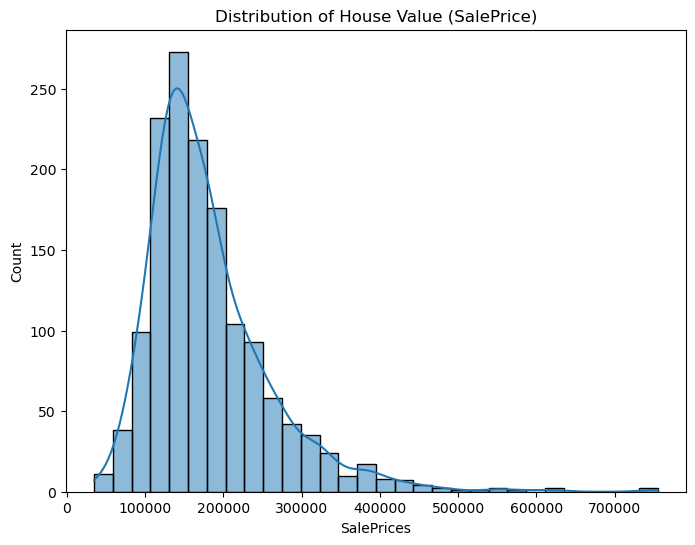

In [19]:
plt.figure(figsize=(8, 6))
sns.histplot(df['SalePrice'], kde=True, bins=30)
plt.title('Distribution of House Value (SalePrice)')
plt.xlabel('SalePrices')
plt.show()

### Question 3: Feature Correlation with Target

In [23]:
numeric_df = df.select_dtypes(include=np.number)
correlation_matrix = numeric_df.corr()


In [24]:
SalePrice_corr = correlation_matrix['SalePrice'].sort_values(ascending=False)

In [30]:
SalePrice_corr.head(10).index

Index(['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea',
       'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt'],
      dtype='object')

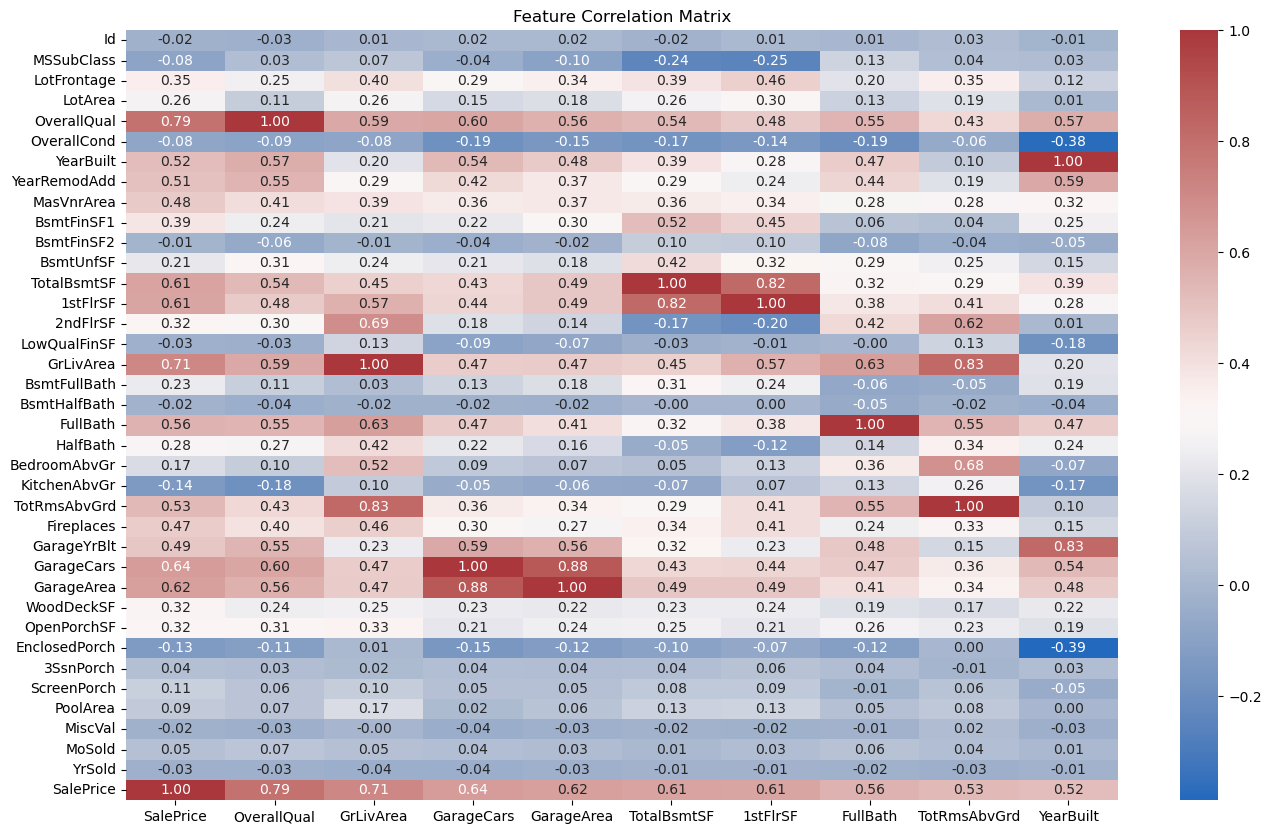

In [33]:
plt.figure(figsize=(16, 10))
sns.heatmap(correlation_matrix[SalePrice_corr.head(10).index], annot=True, fmt=".2f", cmap='vlag')
plt.title('Feature Correlation Matrix')
plt.show() #

### Question 4: Outlier Detection

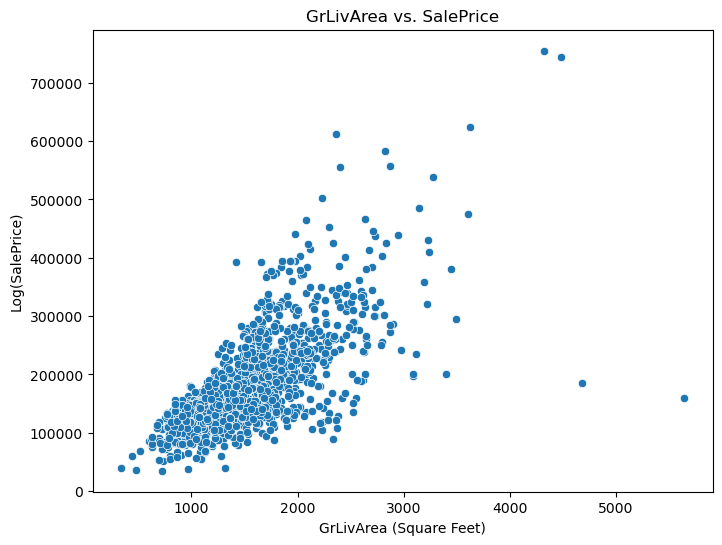

In [41]:
# Does the most influential numerical feature, GrLivArea (Above Ground Living Area), contain significant outliers that could affect the model?
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['GrLivArea'], y=df['SalePrice'])
plt.title('GrLivArea vs. SalePrice')
plt.xlabel('GrLivArea (Square Feet)')
plt.ylabel('Log(SalePrice)')
plt.show()

<Axes: ylabel='GrLivArea'>

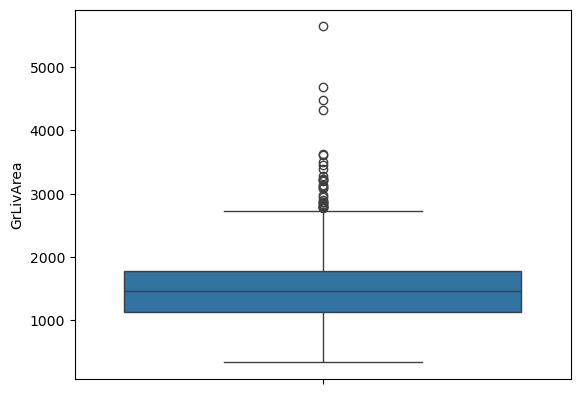

In [42]:
sns.boxplot(y=df['GrLivArea'])

### Question 5: Impact of Categorical Quality Feature
Q: How does OverallQual (Rates the overall material and finish of the house, 1-10) relate to the SalePrice?

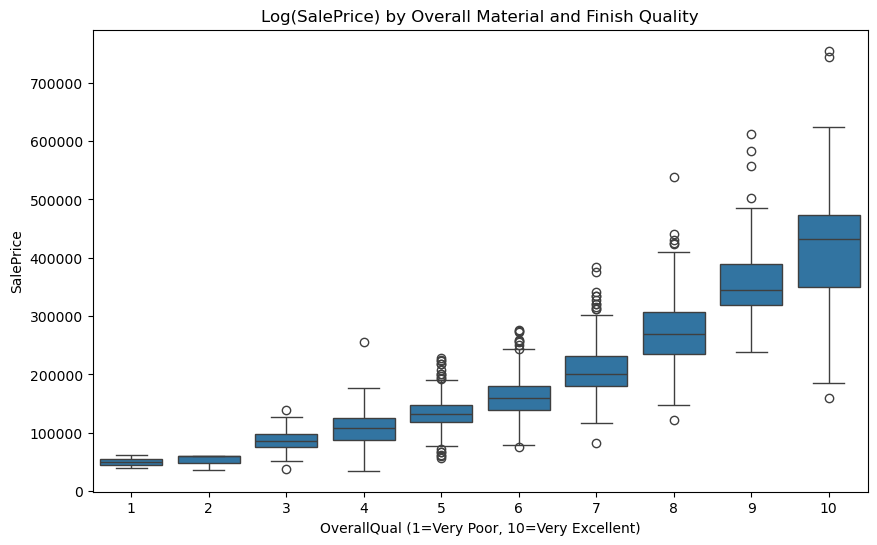

In [44]:
plt.figure(figsize=(10, 6))
# Ensure OverallQual is treated as a category for proper box plot order
sns.boxplot(x='OverallQual', y='SalePrice', data=df)
plt.title('Log(SalePrice) by Overall Material and Finish Quality')
plt.xlabel('OverallQual (1=Very Poor, 10=Very Excellent)')
plt.ylabel('SalePrice')
plt.show()

### Relationship between Year Built and Price
Q: How does the YearBuilt (Original construction date) relate to the SalePrice?

In [47]:
df[['SalePrice','YearBuilt']].corr()

,SalePrice,YearBuilt
SalePrice,1.000000,0.522897
YearBuilt,0.522897,1.000000


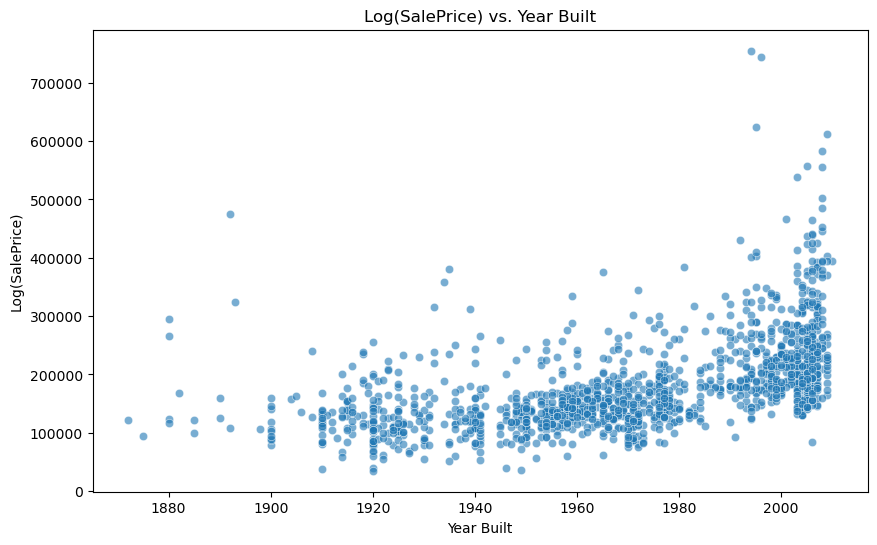

In [45]:
plt.figure(figsize=(10, 6))
# Use a scatter plot to show the trend
sns.scatterplot(x=df['YearBuilt'], y=df['SalePrice'], alpha=0.6)
plt.title('Log(SalePrice) vs. Year Built')
plt.xlabel('Year Built')
plt.ylabel('Log(SalePrice)')
plt.show()

###  Distribution of Garage Size
Q: What is the distribution of GarageCars (Size of garage in car capacity), and what is the price difference between houses with and without a garage?

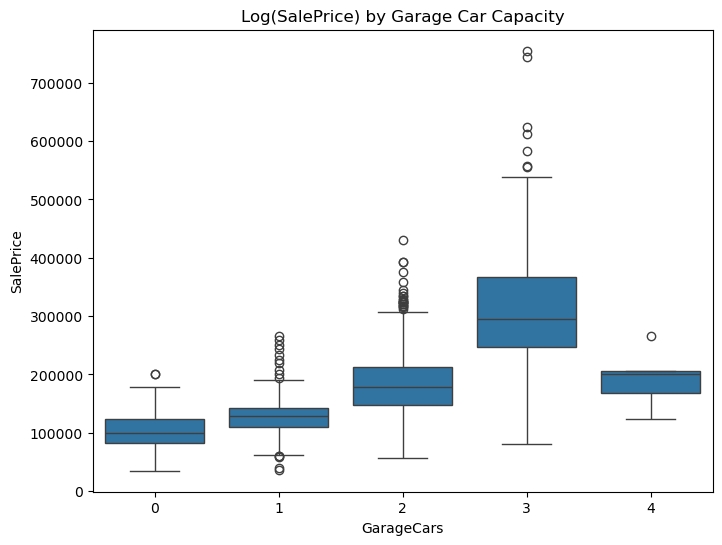

Median Log(SalePrice) for houses with no garage: 100000.00


In [50]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='GarageCars', y='SalePrice', data=df)
plt.title('Log(SalePrice) by Garage Car Capacity')
plt.show()

# Separate the 0-car group (No garage)
no_garage_median = df[df['GarageCars'] == 0]['SalePrice'].median()
print(f"Median Log(SalePrice) for houses with no garage: {no_garage_median:.2f}")

### Feature Interaction (Conditioning the Relationship)    
Q: How does the relationship between the main feature of quality (GrLivArea) and the target (SalePrice_Log) change when conditioned on OverallQual?

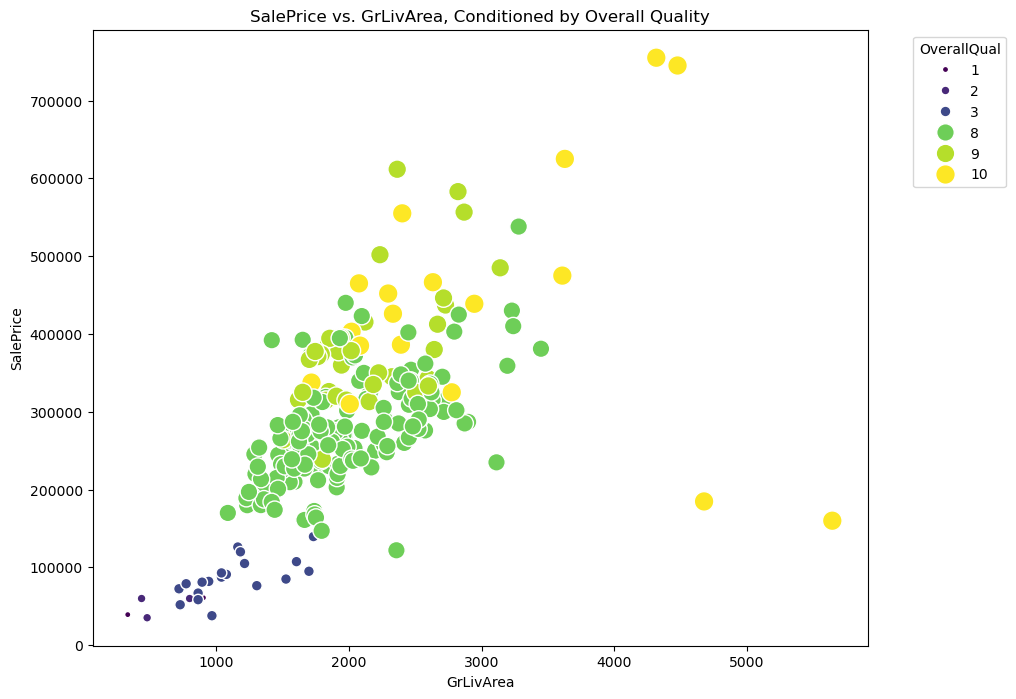

In [51]:
## Solution 11: Feature Interaction using hue
plt.figure(figsize=(10, 8))

# Use the top 3 and bottom 3 OverallQual values for visual clarity
qual_levels = [1, 2, 3, 8, 9, 10]

sns.scatterplot(
    x='GrLivArea', 
    y='SalePrice', 
    hue='OverallQual', 
    data=df[df['OverallQual'].isin(qual_levels)], # Filter for key levels
    palette='viridis', 
    size='OverallQual', 
    sizes=(20, 200)
)

plt.title('SalePrice vs. GrLivArea, Conditioned by Overall Quality')
plt.legend(title='OverallQual', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Observation: We expect to see distinct, higher lines for higher OverallQual groups, 
# indicating high-quality large houses are significantly more expensive.

### Time Series Analysis (Price Trends Over the Years)
Q: Is there a visible price trend (median SalePrice_Log) based on the year the house was sold (YrSold)?

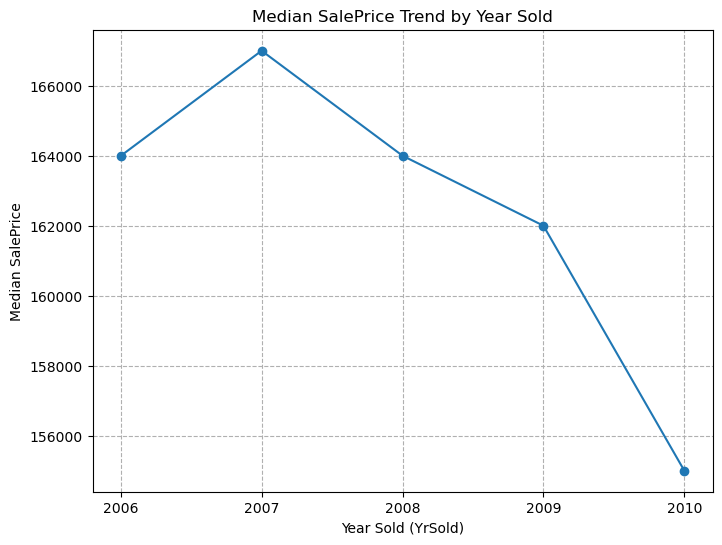

In [53]:
## Solution 12: Price Trends Over Time
plt.figure(figsize=(8, 6))

# Calculate the median SalePrice_Log for each year sold
yearly_prices = df.groupby('YrSold')['SalePrice'].median()

# Plot the trend
yearly_prices.plot(kind='line', marker='o')

plt.title('Median SalePrice Trend by Year Sold')
plt.xlabel('Year Sold (YrSold)')
plt.ylabel('Median SalePrice')
plt.grid(True, linestyle='--')
plt.xticks(yearly_prices.index)
plt.show()

# Observation: You can usually see a slight dip around 2008/2009 (The Great Recession), 
# illustrating real-world economic impacts on the data.

### Feature Discretization and Aggregation
Q: What is the median SalePrice_Log across different categories of age for the homes (e.g., New, Renovated, Old)?

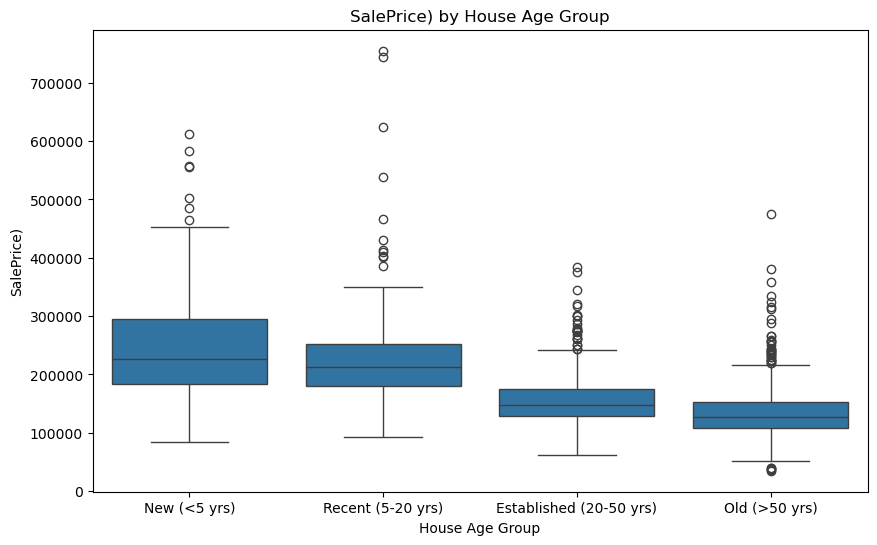


--- Median Log(SalePrice) by Age Group ---
AgeGroup
New (<5 yrs)               226350.0
Recent (5-20 yrs)          213000.0
Established (20-50 yrs)    147250.0
Old (>50 yrs)              127750.0
Name: SalePrice, dtype: float64


C:\Users\Venugopal\AppData\Local\Temp\ipykernel_2112\1316804867.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('AgeGroup')['SalePrice'].median().sort_values(ascending=False))


In [55]:
## Solution 13: Age Discretization and Aggregation

# Calculate the age of the house at the time of sale (simple approximation)
df['HouseAge'] = df['YrSold'] - df['YearBuilt']

# Define age bins/categories (you can adjust these)
bins = [0, 5, 20, 50, df['HouseAge'].max()]
labels = ['New (<5 yrs)', 'Recent (5-20 yrs)', 'Established (20-50 yrs)', 'Old (>50 yrs)']

# Create a new categorical feature: AgeGroup
df['AgeGroup'] = pd.cut(df['HouseAge'], bins=bins, labels=labels, right=False, include_lowest=True)

# Visualize the price distribution across the new AgeGroup
plt.figure(figsize=(10, 6))
sns.boxplot(x='AgeGroup', y='SalePrice', data=df, 
            order=labels) # Ensure boxes are in order

plt.title('SalePrice) by House Age Group')
plt.xlabel('House Age Group')
plt.ylabel('SalePrice)')
plt.show()

# Print the median price for each group
print("\n--- Median Log(SalePrice) by Age Group ---")
print(df.groupby('AgeGroup')['SalePrice'].median().sort_values(ascending=False))